In [1]:
import yaml
import pickle

In [36]:
config_file = "../config_multiscope/podns_vpn_multi_scale5k10k.yaml"
with open(config_file, 'r') as file:
    config = yaml.safe_load(file)

In [37]:
p_filename = "../" + config['experiment_name'] + "_ts.pkl"

with open(p_filename, 'rb') as file:
    src = pickle.load(file)
    dst = pickle.load(file)

In [38]:
dst['/tordata/config/group_0_user_0']

,text_len,count
time,,
2025-06-18 13:31:08.466,86,1
2025-06-18 13:31:11.799,0,0
2025-06-18 13:31:15.132,163,1
2025-06-18 13:31:18.465,0,0
2025-06-18 13:31:21.798,0,0
...,...,...
2025-06-18 13:35:45.105,0,0
2025-06-18 13:35:48.438,0,0
2025-06-18 13:35:51.771,0,0


In [39]:
src['102.0.0.10']

,ip.proto,ip.len,udp.dstport,count,ip.proto_ISP1-all,ip.len_ISP1-all,udp.dstport_ISP1-all,count_ISP1-all,tcp.dstport,tcp.ack,...,ip.proto_VPN-3,ip.len_VPN-3,tcp.dstport_VPN-3,tcp.ack_VPN-3,tcp.len_VPN-3,udp.dstport_VPN-3,tcp.time_relative_VPN-3,tcp.time_delta_VPN-3,count_VPN-3,frame.time
frame.time,,,,,,,,,,,,,,,,,,,,,
2025-06-18 12:07:25.635,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 12:07:25.635
2025-06-18 12:07:28.968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 12:07:28.968
2025-06-18 12:07:32.301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 12:07:32.301
2025-06-18 12:07:35.634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 12:07:35.634
2025-06-18 12:07:38.967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 12:07:38.967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18 13:36:55.098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 13:36:55.098
2025-06-18 13:36:58.431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 13:36:58.431
2025-06-18 13:37:01.764,700.0,1616.0,0.0,14.0,200.0,464.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-06-18 13:37:01.764


In [40]:
import pandas as pd 

def ts2nccvec(ts: pd.core.frame.DataFrame):
    sample_offset = ((len(ts)-1)**0.5)
    return (ts - ts.mean()) / (ts.std()*sample_offset)
    
vec = ts2nccvec(dst['/tordata/config/group_0_user_0']["text_len"])
vec

time
2025-06-18 13:31:08.466    0.043953
2025-06-18 13:31:11.799   -0.032078
2025-06-18 13:31:15.132    0.112028
2025-06-18 13:31:18.465   -0.032078
2025-06-18 13:31:21.798   -0.032078
                             ...   
2025-06-18 13:35:45.105   -0.032078
2025-06-18 13:35:48.438   -0.032078
2025-06-18 13:35:51.771   -0.032078
2025-06-18 13:35:55.104   -0.032078
2025-06-18 13:35:58.437    0.065172
Name: text_len, Length: 88, dtype: float64

In [41]:
import numpy as np
np.dot(vec.to_numpy(), vec.to_numpy())

np.float64(0.9999999999999998)

### Todo
- **Find way to align dataset**
    - chunk, fill zeros, etc
    - _Last big thing to do before all out test of method_
- Get end to end working
    - Send pcaps dfs through ncc GIS stuff
- Run new experiment loop
    - run through all features/combos and report metrics

In [42]:
scale_factor = 300
chunk_size = td = pd.Timedelta(1, "W")/scale_factor
chunk_size

Timedelta('0 days 00:33:36')

In [43]:
start = min([src[ip].index[0] for ip in src])
start

Timestamp('2025-06-18 12:07:25.635000')

In [44]:
# Fill zeros in missing indexes
full_index = pd.Index([])

for ip in src:
    full_index = full_index.union(src[ip].index)
    
for user in dst:
    full_index = full_index.union(dst[user].index)
print(full_index)
for ip in src:
    src[ip] = src[ip].reindex(full_index, fill_value=0)
    assert len(src[ip]) == len(full_index)

for user in dst:
    dst[user] = dst[user].reindex(full_index, fill_value=0)
    assert len(dst[user]) == len(full_index)

Index([2025-06-18 12:07:25.635000, 2025-06-18 12:07:28.968000,
       2025-06-18 12:07:32.301000, 2025-06-18 12:07:35.634000,
       2025-06-18 12:07:38.967000, 2025-06-18 12:07:42.300000,
       2025-06-18 12:07:45.633000, 2025-06-18 12:07:48.966000,
       2025-06-18 12:07:52.299000, 2025-06-18 12:07:55.632000,
       ...
       2025-06-18 13:37:41.760000, 2025-06-18 13:37:45.093000,
       2025-06-18 13:37:48.426000, 2025-06-18 13:37:51.759000,
       2025-06-18 13:37:55.092000, 2025-06-18 13:37:58.425000,
       2025-06-18 13:38:01.758000, 2025-06-18 13:38:05.091000,
       2025-06-18 13:38:08.424000, 2025-06-18 13:38:11.757000],
      dtype='object', length=1635)


In [45]:
src_chunks = {}

for ip in src:
    cur = start
    end = src[ip].index[-1]
    src_chunks[ip] = {}
    
    while cur < end:
        src_chunks[ip][cur] = src[ip][cur:cur+chunk_size]
        cur += chunk_size

dst_chunks = {}

for user in dst:
    cur = start
    end = dst[user].index[-1]
    dst_chunks[user] = {}
    
    while cur < end:
        dst_chunks[user][cur] = dst[user][cur:cur+chunk_size]
        cur += chunk_size

In [46]:
# - fill out zeros in the other timestamps for smaller chunks (could do this before or after chunking)
# - copy NCCTree class over
# - Send through as test (def eval(src_chunks[f], dst_chunks[f], label_func) -> List[Metrics] )
# - Setup experiment full loop (loop over all feature combos and multithread, save out to a file)

In [47]:
#dst_chunks['/tordata/config/group_0_user_0'][pd.Timestamp('2025-05-07 11:02:22.692000')]

In [48]:
def eval_model(src, src_feature, dst, dst_feature, label_func, metric_func) -> {str: float}:
    output = model(src, src_feature, dst, dst_feature)
    labels = label_func(src_chunks)
    return metric_func(output, labels)

In [49]:
import math
def ip_to_user_multi(ip, group_size=5, starting=10):
    num_isps = 10
    isp = int(int(ip.split(".")[-2]))
    node_number = (int(ip.split(".")[-1]) - starting )*num_isps + isp
    user = node_number % group_size
    group = math.floor(node_number / group_size)
    return '/tordata/config/group_' + str(group) + "_user_" + str(user)
    
def label_f(d) -> {str: str}:
    result = {}
    for k in d:
        result[k] = ip_to_user_multi(k)
    return result

print(src.keys())
print(ip_to_user_multi('102.0.8.13'))

dict_keys(['102.0.9.10', '102.0.6.14', '102.0.6.11', '102.0.7.16', '102.0.8.18', '102.0.6.13', '102.0.0.14', '102.0.4.17', '102.0.5.17', '102.0.2.12', '102.0.9.19', '102.0.6.12', '102.0.3.12', '102.0.1.12', '102.0.3.14', '102.0.0.11', '102.0.7.11', '102.0.5.11', '102.0.9.11', '102.0.2.10', '102.0.2.16', '102.0.5.14', '102.0.6.10', '102.0.4.14', '102.0.5.13', '102.0.2.15', '102.0.1.11', '102.0.7.13', '102.0.6.17', '102.0.5.18', '102.0.3.18', '102.0.3.17', '102.0.5.12', '102.0.6.16', '102.0.3.19', '102.0.9.12', '102.0.8.17', '102.0.4.18', '102.0.8.19', '102.0.0.18', '102.0.4.12', '102.0.7.14', '102.0.7.18', '102.0.3.16', '102.0.2.17', '102.0.1.16', '102.0.7.17', '102.0.5.15', '102.0.7.10', '102.0.1.19', '102.0.9.15', '102.0.0.10', '102.0.4.15', '102.0.2.14', '102.0.2.11', '102.0.4.11', '102.0.6.19', '102.0.4.16', '102.0.1.15', '102.0.9.18', '102.0.1.18', '102.0.3.15', '102.0.9.17', '102.0.9.16', '102.0.0.15', '102.0.8.10', '102.0.0.13', '102.0.6.18', '102.0.5.16', '102.0.0.19', '102.0.6.

In [50]:
#from functools import lru_cache

#@lru_cache(maxsize=None) 
def metric_match(x, y, yi):
    return  x == y[yi][0]

#@lru_cache(maxsize=None) 
def accuracy(output, labels) -> float:
    if len(output) == 0:
        return 0.
    correct = 0.0
    for x in output:
        if metric_match(labels[x], output[x], 0):
            correct += 1.
    accuracy = correct/len(output)
    return accuracy

#@lru_cache(maxsize=None) 
def rank(output, labels) -> [float]:
    result = [0.]*len(output)
    
    for idx, x in enumerate(output):
        for yi in range(len(output[x])):
            if metric_match(labels[x], output[x], yi):
                result[idx] = yi + 1
                break
        if result[idx] == 0:
            print(x)
        #assert result[idx] != 0
                
    return result

#@lru_cache(maxsize=None) 
def recall_k_f(k):
    def recall_k(output, labels) -> float:
        ranks = rank(output, labels)
        # Must remove values that are 0. These are values that could not be found
        ranks = filter(lambda x: x != 0., ranks)
        return sum([1. if r <= k else 0. for r in ranks])/len(output)
    return recall_k

#@lru_cache(maxsize=None) 
def precision_k_f(k):  
    def precision_k(output, labels) -> float:
        return recall_k_f(k)(output, labels) / float(k)
    return precision_k

#@lru_cache(maxsize=None) 
def f_beta_k_f(k, beta=1.):  
    def f_beta_k(output, labels) -> float:
        recall = recall_k_f(k)(output, labels)
        precision = precision_k_f(k)(output, labels)
        top = (1. + beta * beta) * recall * precision 
        bottom = (beta * beta * precision) + recall
        if bottom == 0:
            return 0
        return top / bottom
    return f_beta_k

#@lru_cache(maxsize=None) 
def MRR(output, labels) -> float:
    ranks = rank(output, labels)
    # Must remove values that are 0. These are values that could not be found
    ranks = filter(lambda x: x != 0., ranks)
    return sum([1./r for r in ranks])/len(output)

In [51]:
def all_metrics(output, labels):
    metrics = [
        ("Accuracy", accuracy),
        
        ("Recall@1", recall_k_f(1)),
        ("Recall@2", recall_k_f(2)),
        ("Recall@4", recall_k_f(4)),
        ("Recall@8", recall_k_f(8)),
        
        ("Precision@1", precision_k_f(1)),
        ("Precision@2", precision_k_f(2)),
        ("Precision@4", precision_k_f(4)),
        ("Precision@8", precision_k_f(8)),

        ("F-beta@1", f_beta_k_f(1)),
        ("F-beta@2", f_beta_k_f(2)),
        ("F-beta@4", f_beta_k_f(4)),
        ("F-beta@8", f_beta_k_f(8)),

        ("MRR", MRR),

        ("Rank", rank)
    ]

    return {m[0]: m[1](output, labels) for m in metrics}
    
def get_metric_names(m_f):
    return list(m_f({"": [("", 1)]}, {"": ""}).keys())


In [52]:
import sys
import os
from tqdm import tqdm
sys.path.append("./NCC")
from NCC import NCCTree

def get_ts(p, feature):
    if feature not in p:
        return np.zeros(1)
    #time = pd.Timestamp('2025-05-07 11:02:22.692000')
    #return p[time][feature].to_numpy()
    return p[feature].to_numpy()

def model(src_chunks, src_feature, dst_chunks, dst_feature, disable_bar=False) -> {str: [(str, float)]}:
    result = {}

    #noise_floor = np.mean([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])
    
    tree = NCCTree(len(src_chunks[list(src_chunks.keys())[0]]))
    for p in tqdm(dst_chunks, disable=disable_bar):
        ts = get_ts(dst_chunks[p], dst_feature)
        # advoid divide by zero if all zeros 
        #if (ts == 0).all(): continue
        vec = ts2nccvec(ts)
        assert abs(1 - np.linalg.norm(vec)) < 0.001
        tree.insert(vec, p)

    #for _ in range(10):
    for p in tqdm(src_chunks, disable=disable_bar):
        ts = get_ts(src_chunks[p], src_feature)
        #if (ts == 0).all(): continue
        vec = ts2nccvec(ts)
        #vec[vec < noise_floor] = 0
        n = tree.ncc(vec, 100)
        #print(ip_to_user_multi(p), n)
        result[p] = n
    
    # if in and out are set to the same then this confirms it works correctly
    # assert(all(n[i] >= n[i + 1] for i in range(len(n) - 1)))
    
    return result
#out = model(src, 'count_ISP1-3', dst, 'count')

In [53]:
%%time
eval_model(src, 'count', dst, 'count', label_f, all_metrics)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 828.09it/s]

102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15

{'Accuracy': 0.87,
 'Recall@1': 0.87,
 'Recall@2': 0.89,
 'Recall@4': 0.89,
 'Recall@8': 0.89,
 'Precision@1': 0.87,
 'Precision@2': 0.445,
 'Precision@4': 0.2225,
 'Precision@8': 0.11125,
 'F-beta@1': 0.87,
 'F-beta@2': 0.5933333333333334,
 'F-beta@4': 0.356,
 'F-beta@8': 0.1977777777777778,
 'MRR': 0.88,
 'Rank': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0.0,
  0.0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0.0,
  1,
  1,
  1,
  1,
  1,
  1,
  0.0,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0.0,
  1,
  1,
  0.0,
  0.0,
  1,
  1,
  1,
  1,
  1,
  0.0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0.0,
  1,
  0.0,
  1,
  1,
  0.0,
  1,
  1]}

In [54]:
def eval_all(src, dst, label_f, metric_f):
    # WARN: This assumes all entries have the same features
    src_features = list(src.values())[0].columns
    dst_features = list(dst.values())[0].columns
    bad_features = ['frame.time']

    metric_names = get_metric_names(metric_f)

    results = pd.DataFrame(columns=['src_feature', 'dst_feature'] + metric_names)
    for df in dst_features:
        for sf in tqdm(src_features):
            if sf in bad_features: continue
            results.loc[len(results)] = {
                'src_feature': sf, 
                'dst_feature': df,
            } | eval_model(src, sf, dst, df, label_f, metric_f)
    return results

model_all_out = eval_all(src, dst, label_f, all_metrics)
model_all_out

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:00<00:00, 1704.81it/s]

  2%|████▍                                                                                                                                                                                                                  | 1/49 [00:00<00:08,  5.57it/s]

102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:00<00:00, 1881.38it/s]

  4%|████████▊                                                                                                                                                                                                              | 2/49 [00:00<00:08,  5.66it/s]

102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:00<00:00, 1834.45it/s]

  0%|                                                                                                                                                                                                                              | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_8924/1028957165.py:5: RuntimeWarning: invalid value encountered in divide
  return (ts - ts.mean()) / (ts.std()*sample_offset)

  6%|█████████████▏                                                                                                                                                                                                         | 3/49 [00:00<00:08,  5.57it/s]

...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:00<00:00, 2041.40it/s]

  0%|                                                                                                                                                                                                                              | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_8924/1028957165.py:5: RuntimeWarning: invalid value encountered in divide
  return (ts - ts.mean()) / (ts.std()*sample_offset)
 96%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎        | 47/49 [00:06<00:00,  6.88it/s]

102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:00<00:00, 2068.03it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:07<00:00,  6.90it/s]

102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15
102.0.2.11
102.0.6.15
102.0.1.10
102.0.8.15
102.0.7.19
102.0.7.15
102.0.1.14
102.0.4.19
102.0.9.12
102.0.8.17
102.0.5.15

,src_feature,dst_feature,Accuracy,Recall@1,Recall@2,Recall@4,Recall@8,Precision@1,Precision@2,Precision@4,Precision@8,F-beta@1,F-beta@2,F-beta@4,F-beta@8,MRR,Rank
0,ip.proto,text_len,0.82,0.82,0.87,0.89,0.89,0.82,0.435,0.2225,0.11125,0.82,0.580000,0.356,0.197778,0.850833,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,ip.len,text_len,0.83,0.83,0.88,0.89,0.89,0.83,0.440,0.2225,0.11125,0.83,0.586667,0.356,0.197778,0.858333,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,tcp.dstport,text_len,0.02,0.02,0.03,0.05,0.09,0.02,0.015,0.0125,0.01125,0.02,0.020000,0.020,0.020000,0.060536,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."
3,tcp.ack,text_len,0.02,0.02,0.03,0.05,0.09,0.02,0.015,0.0125,0.01125,0.02,0.020000,0.020,0.020000,0.060536,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."
4,tcp.len,text_len,0.02,0.02,0.03,0.05,0.09,0.02,0.015,0.0125,0.01125,0.02,0.020000,0.020,0.020000,0.060536,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,tcp.len_VPN-3,count,0.01,0.01,0.02,0.04,0.08,0.01,0.010,0.0100,0.01000,0.01,0.013333,0.016,0.017778,0.050715,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."
92,udp.dstport_VPN-3,count,0.00,0.00,0.04,0.05,0.08,0.00,0.020,0.0125,0.01000,0.00,0.026667,0.020,0.017778,0.050952,"[17, 78, 79, 27, 59, 19, 64, 36, 72, 68, 25, 5..."
93,tcp.time_relative_VPN-3,count,0.01,0.01,0.02,0.04,0.08,0.01,0.010,0.0100,0.01000,0.01,0.013333,0.016,0.017778,0.050715,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."
94,tcp.time_delta_VPN-3,count,0.01,0.01,0.02,0.04,0.08,0.01,0.010,0.0100,0.01000,0.01,0.013333,0.016,0.017778,0.050715,"[34, 70, 65, 41, 63, 13, 89, 23, 39, 3, 16, 80..."


In [55]:
model_all_out.sort_values(by='Accuracy', ascending=False).head(40)

,src_feature,dst_feature,Accuracy,Recall@1,Recall@2,Recall@4,Recall@8,Precision@1,Precision@2,Precision@4,Precision@8,F-beta@1,F-beta@2,F-beta@4,F-beta@8,MRR,Rank
68,ip.proto_VPN-1,count,0.87,0.87,0.88,0.88,0.89,0.87,0.440,0.2200,0.11125,0.87,0.586667,0.352,0.197778,0.876667,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
77,count_VPN-1,count,0.87,0.87,0.88,0.88,0.89,0.87,0.440,0.2200,0.11125,0.87,0.586667,0.352,0.197778,0.876667,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
57,count,count,0.87,0.87,0.89,0.89,0.89,0.87,0.445,0.2225,0.11125,0.87,0.593333,0.356,0.197778,0.880000,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
49,ip.len,count,0.86,0.86,0.89,0.89,0.89,0.86,0.445,0.2225,0.11125,0.86,0.593333,0.356,0.197778,0.875000,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
67,count_VPN-all,count,0.86,0.86,0.88,0.88,0.89,0.86,0.440,0.2200,0.11125,0.86,0.586667,0.352,0.197778,0.871667,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
58,ip.proto_VPN-all,count,0.86,0.86,0.88,0.88,0.89,0.86,0.440,0.2200,0.11125,0.86,0.586667,0.352,0.197778,0.871667,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
48,ip.proto,count,0.86,0.86,0.88,0.89,0.89,0.86,0.440,0.2225,0.11125,0.86,0.586667,0.356,0.197778,0.873333,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
59,ip.len_VPN-all,count,0.85,0.85,0.88,0.88,0.89,0.85,0.440,0.2200,0.11125,0.85,0.586667,0.352,0.197778,0.866667,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
95,count_VPN-3,count,0.85,0.85,0.88,0.88,0.89,0.85,0.440,0.2200,0.11125,0.85,0.586667,0.352,0.197778,0.866429,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
87,ip.proto_VPN-3,count,0.85,0.85,0.88,0.88,0.88,0.85,0.440,0.2200,0.11000,0.85,0.586667,0.352,0.195556,0.866111,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [28]:
def best_scopes(results):
    pass

In [29]:
def smallest_gt_zero(df):
    return min(df[df > 0])
#smallest_gt_zero(y2)

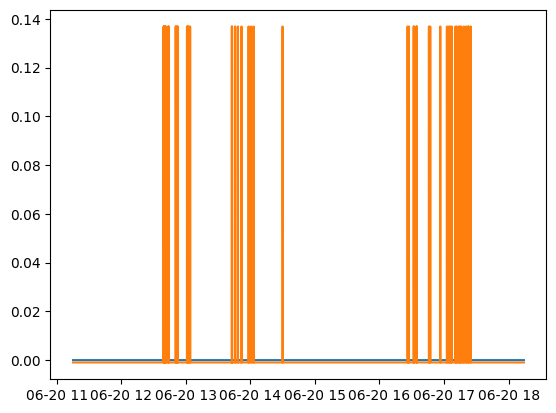

np.float64(0.0)

In [30]:
import matplotlib.pyplot as plt
import datetime

noise_floor = np.mean([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])

x = src['102.0.0.10'].index
y = ts2nccvec(src['102.0.0.10']['count'])
y2 = ts2nccvec(dst['/tordata/config/group_0_user_0']['count'])

y.loc[y < noise_floor] = 0


plt.plot(x,y)
plt.plot(x, y2)
plt.show()
np.dot(y.to_numpy(), y2.to_numpy())#/np.dot(y.to_numpy(), y.to_numpy())

In [31]:
pd.unique(y2)
y2

2025-06-20 11:15:05.949   -0.000968
2025-06-20 11:15:09.282   -0.000968
2025-06-20 11:15:12.615   -0.000968
2025-06-20 11:15:15.948   -0.000968
2025-06-20 11:15:19.281   -0.000968
                             ...   
2025-06-20 18:14:03.435   -0.000968
2025-06-20 18:14:06.768   -0.000968
2025-06-20 18:14:10.101   -0.000968
2025-06-20 18:14:13.434   -0.000968
2025-06-20 18:14:16.767   -0.000968
Name: count, Length: 7547, dtype: float64

In [32]:
np.min([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])

np.float64(0.08314429836139443)

In [33]:
list(src['102.0.0.10'].columns)

['ip.proto',
 'ip.len',
 'udp.dstport',
 'count',
 'ip.proto_ISP1-all',
 'ip.len_ISP1-all',
 'udp.dstport_ISP1-all',
 'count_ISP1-all',
 'tcp.dstport',
 'tcp.ack',
 'tcp.len',
 'tcp.time_relative',
 'tcp.time_delta',
 'ip.proto_ISP1-1',
 'ip.len_ISP1-1',
 'tcp.dstport_ISP1-1',
 'tcp.ack_ISP1-1',
 'tcp.len_ISP1-1',
 'udp.dstport_ISP1-1',
 'tcp.time_relative_ISP1-1',
 'tcp.time_delta_ISP1-1',
 'count_ISP1-1',
 'ip.proto_ISP1-2',
 'ip.len_ISP1-2',
 'tcp.dstport_ISP1-2',
 'tcp.ack_ISP1-2',
 'tcp.len_ISP1-2',
 'udp.dstport_ISP1-2',
 'tcp.time_relative_ISP1-2',
 'tcp.time_delta_ISP1-2',
 'count_ISP1-2',
 'ip.proto_ISP1-3',
 'ip.len_ISP1-3',
 'tcp.dstport_ISP1-3',
 'tcp.ack_ISP1-3',
 'tcp.len_ISP1-3',
 'udp.dstport_ISP1-3',
 'tcp.time_relative_ISP1-3',
 'tcp.time_delta_ISP1-3',
 'count_ISP1-3',
 'count_cache',
 'ip.proto_root',
 'ip.len_root',
 'udp.dstport_root',
 'count_cache_root',
 'ip.len_SLD',
 'udp.dstport_SLD',
 'count_cache_SLD',
 'ip.proto_TLD',
 'ip.len_TLD',
 'udp.dstport_TLD',
 '

In [34]:
def model_OLD(src_raw, src_feature, dst_raw, dst_feature):
    import statsmodels.api as sm
    def ccf_calc(sig1, sig2):
        corr = sm.tsa.stattools.ccf(sig2, sig1, adjusted=False, nlags=1)
    
        # Remove padding and reverse the order
        return corr[0:(len(sig2)+1)][::-1]


    def cross_cor(ts1, ts2, debug=False, max_offset=300, only_positive=True):
        ccf = ccf_calc(ts1, ts2)
        best_cor = max(ccf)
        best_lag = np.argmax(ccf)
    
        if debug:
            print('best cross correlation: ' + str(best_cor) + " at time lag: " + str(best_lag))
            print(len(ccf))
            print(ccf)
            ccf_plot(range(len(ccf)), ccf)
        return best_cor, best_lag

    def compare_ts(ts1, ts2, debug=False):
        # dtw_classic, path_classic = dtw(ts1, ts2, dist='square',
        #                             method='classic', return_path=True)
        # return dtw_classic
        # print(ts1)
        # print(ts2)
        # dist, lag = cross_cor(pd.Series(ts1), pd.Series(ts2))
        dist, lag = cross_cor(ts1, ts2, debug=debug)
        # assert dist >= -1 and dist <= 1
        dist = dist * -1  # flip for use as distance metric
        # assert dist >= -1 and dist <= 1
        return dist, lag

    def compare_ts_reshape(ts1, ts2, debug=False):
        ts1 = ts1.fillna(0)
        ts2 = ts2.fillna(0)
    
        range = min(ts2.index.values), max(ts2.index.values)
        ts1 = ts1.loc[(ts1.index >= range[0]) & (ts1.index <= range[1])]
    
        # ts1 = ts1.loc[:, 'tda_pl']
        ts1 = ts1.values
    
        ts1_norm = np.array(ts1)
        ts2_norm = np.array(ts2)
    
        # delay = 0
    
        # ts1_norm.index = ts1_norm.index + pd.DateOffset(seconds=delay)
    
        # lock to same range with buffer room
        # on each side to account for network (or PPT) delay
    
        # detect if no overlap
        if len(ts1_norm) < 2 or len(ts2_norm) < 2:
            return float("inf"), 0
    
        # Normalize peaks?
        # ts1_norm = normalize_ts(ts1_norm)
        # ts2_norm = normalize_ts(ts2_norm)
    
        # plot_ts(ts1_norm, ts2_norm)
        # exit(1)
    
        # else:
        #     ts1_norm = ts1_norm.tolist()
        #     ts2_norm = ts2_norm.tolist()
    
        score, lag = compare_ts(ts1_norm, ts2_norm, debug=debug)
        # adj_score = score + (((lag+1)**1.1)/1000.0)
        return score, lag

    src = {}
    dst = {}
    for ip in src_raw:
        src[ip] = src_raw[ip][src_feature]
    for user in dst_raw:
        dst[user] = dst_raw[user][dst_feature]
        
    correct = 0.0
    for user in dst:
        best_score = 0
        best_user = 0
        #for _ in range(10):
        for ip in src:
            score = sm.tsa.stattools.ccf(src[ip].values, dst[user].values, adjusted=False, nlags=1)
            if score > best_score:
                best_score = score
                best_user = ip_to_user_multi(ip)
        if user == best_user:
            correct += 1
    accuracy = correct / len(src)
    return accuracy

In [35]:
%%time
model_OLD(src, 'count', dst, 'count')

CPU times: user 5.63 s, sys: 112 ms, total: 5.74 s
Wall time: 5.22 s


0.97